# Homework 5

Custom Least Squares Method

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(99)

def my_lstsq(x, y):
    n = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_x2 = sum([i**2 for i in x])
    sum_xy = sum([i*j for i, j in zip(x, y)])
    
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    c = (sum_y - m * sum_x) / n
    return m, c

## Testing

   Original: m=1.60, b=0.70
My Function: m=1.57, b=0.71
NP Function: m=1.57, b=0.71
Residuals:  [-0.34455712  0.0238432  -0.65099035  0.93710722 -0.61609993 -0.13123484
  0.404755    0.90660856 -0.9812548   0.98634853 -0.53958606 -0.4935342
  0.24512213  0.0117051  -0.85789678  0.20909191 -0.94791259 -0.04882943
  0.81277381 -0.62661683  0.57662643 -0.10869157  0.41546177 -0.63228472
 -0.65608513  0.55684526 -0.2896694   0.80963676  0.17667352  0.80626948
  0.711978    0.57560765  0.04668769  0.84477233  0.52991244  0.98689399
 -0.79728837 -0.10446885  0.66490674 -0.85775637 -0.0841754   0.91648294
 -0.04975368 -0.28028508 -0.60131633 -0.6698377   0.49473554 -0.93654703
  0.06752373  0.47181766 -0.09875684  0.24533243  0.5925433  -0.830925
 -0.87835485 -0.67498719  0.13442133 -0.4322259  -0.70268798  0.84190663
  0.18008293 -0.2831402  -0.95290264 -0.41057672 -0.27324021  0.58922658
  0.41386977  0.67997985  0.39213359 -0.43701276 -0.91596     0.96843556
  0.37481108  0.90217463 -0.749

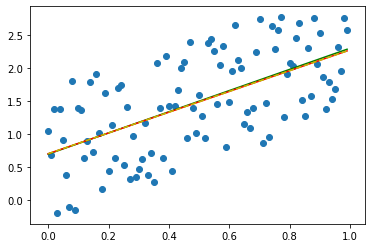

In [2]:
m = 1.6
b = 0.7
x = np.arange(0, 1, 0.01)
y = m*x + b + (2*np.random.random(size=len(x)) - 1)

my_m, my_b = my_lstsq(x, y)

A = np.vstack([x, np.ones(len(x))]).T
np_m, np_b = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"   Original: m={m:.2f}, b={b:.2f}")
print(f"My Function: m={my_m:.2f}, b={my_b:.2f}")
print(f"NP Function: m={np_m:.2f}, b={np_b:.2f}")

residuals = np.array([[m*i + b - j, i] for i, j in zip(x, y)], dtype=float)
print("Residuals: ", residuals[:,0])
print(f"Max R: {max(residuals[:,0]):.3f} at x={residuals[np.argmax(residuals[:,0]),1]:.3f}")
print(f"Min R: {min(residuals[:,0]):.3f} at x={residuals[np.argmin(residuals[:,0]),1]:.3f}")
print("\nGreen: Original")
print("Yellow: Numpy")
print("Red: Mine")

xs = np.array([min(x),max(x)])
plt.scatter(x, y)
plt.plot(xs, m*xs + b, 'g-')
plt.plot(xs, my_m*xs + my_b, 'r-')
plt.plot(xs, np_m*xs + np_b, 'y--')
plt.show()